## 4) Notebook for Section 4 of Paper: Adaptation

##### Before running this notebook, you need to run the following snakemake commands to produce the necessary outputs
##### Note: Some files from Notebook 2 are required to run this notebook (baseline risk CI metrics). 
1) snakemake -c1 bulk_flood_risk_and_adaptation_analysis (runs flood risk assessment for baseline and adaptation scenarios)
2) snakemake -c1 bulk_social_metrics_adaptation (runs CI analysis for all adaptation scenarios)

##### 1) Import Libraries

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import geopandas as gpd
import numpy as np
import os
import yaml
from pathlib import Path
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, ListedColormap, BoundaryNorm
from matplotlib.colorbar import ColorbarBase
import matplotlib.patches as mpatches
import matplotlib as mpl
from adjustText import adjust_text

##### 2) Config - User Inputs

In [2]:
# Analysis parameters
ADM_level = 'ADM0' # admin level at which we are running the analysis
model = 'jrc' # flood model used
# Adaptation parameters
fp_urban = '30' # minimum urbanization level to apply flood protection (30 = cities in GHSL DUC)
fp_RP = '100' # level of design protection for flood protection 
dry_proof_unit_cost = 0.05 # unit cost of dry-proofing buildings % of building capital stock dry-proofed
rl_urban = '13' # maximum urbanization elgible for relocation (13 = densest rural grid cell)
relocation_cost = 3  # cost of relocation a building 3x the building capital stock - to account for rebuilding and relocation (conservative)
# Benefit-Cost analysis parameters
fp_time_period = 80 # time period over which to calculate flood protection BCR (flood walls have long design lives)
rl_time_period = 50 # time period over which to calcualte relocation BCR (50-years as significant period of someones lifetime)
dp_time_period = 10 # time period over which to calculate dry-proofing BCR (building-level improvements have shorter design life)
discount_rate = 0.03 # apply a single discount rate across all adaptation scenarios 

##### 3) Define Functions

In [3]:
# Define function combining country inequality metric geopackages
def combine_national_bcr_metrics(country_list, model, ADM_level, fp_urban, fp_rp, rl_urban):
    '''
    Function for combining country's BCR metrics. This function takes as input
        - the list of countries to combine (ISO3 codes)
        - the flood model used (giri, jrc, or wri)
        - the administrative level to focus on (ADM0, ADM1, ADM2)
        - the GHS urbanization threshold for flood protection (21, 22, 23, etc.)
        - the design level of flood protection (50, 100)
        - the GHS urbanization threshold for relocation (11, 12, 23, etc.)
    The outputs of this function are:
        - a combined geodataframe of baseline risk metrics
        - a combined geodataframe of adapted (flood protection) risk metrics
        - a combined geodataframe of adapted (dry proofing) risk metrics
        - a combined geodataframe of adapted (relocation) risk metrics
        - a combined goedataframe of adaptation costs (flood protection)
        - a combined goedataframe of adaptation costs (dry proofing)
        - a combined geodataframe of adaptation costs (relocation)
    '''
    # Lists to store individual GeoDataFrames
    baseline_gdfs = []
    adapted_fp_gdfs = []
    adapted_dp_gdfs = []
    adapted_rl_gdfs = []
    cost_fp_gdfs = []
    cost_dp_gdfs = []
    cost_rl_gdfs = []
    # Loop over all countries in the country list
    for country in country_list:
        try:
            baseline_path = os.path.join("..", "data", "results", "flood_risk", "summary", "countries", 
                                                country, f"{country}_{ADM_level}_metrics_{model}-flood_AALs_baseline_capstock.gpkg")
            adapted_fp_path = os.path.join("..", "data", "results", "flood_risk", "summary", "countries",
                                          country, f"{country}_{ADM_level}_metrics_{model}-flood_AALs_adapted_fp_rp{fp_rp}_duc{fp_urban}_capstock.gpkg")
            adapted_dp_path = os.path.join("..", "data", "results", "flood_risk", "summary", "countries",
                                          country, f"{country}_{ADM_level}_metrics_{model}-flood_AALs_adapted_dp_capstock.gpkg")
            adapted_rl_path = os.path.join("..", "data", "results", "flood_risk", "summary", "countries",
                                          country, f"{country}_{ADM_level}_metrics_{model}-flood_AALs_adapted_rl_duc{rl_urban}_capstock.gpkg")
            cost_fp_path = os.path.join("..", "data", "results", "adaptation", "costs", "countries",
                                       country, f"{country}_adaptation-cost_fp_rp{fp_rp}_duc{fp_urban}_{ADM_level}.gpkg")
            cost_dp_path = os.path.join("..", "data", "results", "adaptation", "costs", "countries",
                                       country, f"{country}_adaptation-cost_dp_m-{model}_{ADM_level}.gpkg")
            cost_rl_path = os.path.join("..", "data", "results", "adaptation", "costs", "countries",
                                       country, f"{country}_adaptation-cost_rl_m-{model}_duc{rl_urban}_{ADM_level}.gpkg")
            # Read the GeoPackages
            gdf_baseline = gpd.read_file(baseline_path)
            gdf_adapted_fp = gpd.read_file(adapted_fp_path)
            gdf_adapted_dp = gpd.read_file(adapted_dp_path)
            gdf_adapted_rl = gpd.read_file(adapted_rl_path)
            gdf_cost_fp = gpd.read_file(cost_fp_path)
            gdf_cost_dp = gpd.read_file(cost_dp_path)
            gdf_cost_rl = gpd.read_file(cost_rl_path)
            # Append to list
            baseline_gdfs.append(gdf_baseline)
            adapted_fp_gdfs.append(gdf_adapted_fp)
            adapted_dp_gdfs.append(gdf_adapted_dp)
            adapted_rl_gdfs.append(gdf_adapted_rl)
            cost_fp_gdfs.append(gdf_cost_fp)
            cost_dp_gdfs.append(gdf_cost_dp)
            cost_rl_gdfs.append(gdf_cost_rl)
        except Exception as e:
            print(f"Error processing {country}: {e}")

    # Combine all GeoDataFrames
    combined_baseline_gdf = pd.concat(baseline_gdfs, ignore_index=True)
    combined_adapted_fp_gdf = pd.concat(adapted_fp_gdfs, ignore_index=True)
    combined_adapted_dp_gdf = pd.concat(adapted_dp_gdfs, ignore_index=True)
    combined_adapted_rl_gdf = pd.concat(adapted_rl_gdfs, ignore_index=True)
    combined_cost_fp_gdf = pd.concat(cost_fp_gdfs, ignore_index=True)
    combined_cost_dp_gdf = pd.concat(cost_dp_gdfs, ignore_index=True)
    combined_cost_rl_gdf = pd.concat(cost_rl_gdfs, ignore_index=True)
    
    return combined_baseline_gdf, combined_adapted_fp_gdf, combined_adapted_dp_gdf, combined_adapted_rl_gdf, combined_cost_fp_gdf, combined_cost_dp_gdf, combined_cost_rl_gdf

def combine_national_CI_metrics(country_list, model, fp_urban, fp_rp, rl_urban):
    '''
    Function for combining country's CI metrics at ADM0. This function takes as input
        - the list of countries to combine (ISO3 codes)
        - the flood model used (giri, jrc, or wri)
        - the GHS urbanization threshold for flood protection (21, 22, 23, etc.)
        - the design level of flood protection (50, 100)
        - the GHS urbanization threshold for relocation (11, 12, 23, etc.)
    The outputs of this function are:
        - a combined geodataframe of baseline CI metrics
        - a combined geodataframe of adapted (flood protection) CI metrics
        - a combined geodataframe of adapted (dry proofing) CI metrics
        - a combined geodataframe of adapted (relocation) CI metrics
    '''
    # Lists to store individual GeoDataFrames
    baseline_gdfs = []
    adapted_fp_gdfs = []
    adapted_dp_gdfs = []
    adapted_rl_gdfs = []
    # Loop over all countries in the country list
    for country in country_list:
        try:
            baseline_path = os.path.join("..", "data", "results", "social_flood", "countries", country, "inequality_metrics", 
                                            f"{country}_ADM0_metrics_{model}-flood_protected_AAR_V-JRC_S-rwi.gpkg")
            adapted_fp_path = os.path.join("..", "data", "results", "social_flood", "countries", country, "inequality_metrics", 
                                            f"{country}_ADM0_metrics_{model}-flood_adapted_AAR_V-JRC_S-rwi_fp_rp{fp_rp}_duc{fp_urban}.gpkg")
            adapted_dp_path = os.path.join("..", "data", "results", "social_flood", "countries", country, "inequality_metrics", 
                                            f"{country}_ADM0_metrics_{model}-flood_adapted_AAR_V-JRC_S-rwi_dp.gpkg")
            adapted_rl_path = os.path.join("..", "data", "results", "social_flood", "countries", country, "inequality_metrics", 
                                            f"{country}_ADM0_metrics_{model}-flood_adapted_AAR_V-JRC_S-rwi_rl_duc{rl_urban}.gpkg")
            # Read the GeoPackages
            gdf_baseline = gpd.read_file(baseline_path)
            gdf_adapted_fp = gpd.read_file(adapted_fp_path)
            gdf_adapted_dp = gpd.read_file(adapted_dp_path)
            gdf_adapted_rl = gpd.read_file(adapted_rl_path)
            # Append to list
            baseline_gdfs.append(gdf_baseline)
            adapted_fp_gdfs.append(gdf_adapted_fp)
            adapted_dp_gdfs.append(gdf_adapted_dp)
            adapted_rl_gdfs.append(gdf_adapted_rl)
        except Exception as e:
            print(f"Error processing {country}: {e}")

    # Combine all GeoDataFrames
    combined_baseline_gdf = pd.concat(baseline_gdfs, ignore_index=True)
    combined_adapted_fp_gdf = pd.concat(adapted_fp_gdfs, ignore_index=True)
    combined_adapted_dp_gdf = pd.concat(adapted_dp_gdfs, ignore_index=True)
    combined_adapted_rl_gdf = pd.concat(adapted_rl_gdfs, ignore_index=True)

    return combined_baseline_gdf, combined_adapted_fp_gdf, combined_adapted_dp_gdf, combined_adapted_rl_gdf

# Define BCR function
def calculate_bcr(baseline_df, adapted_df, cost_df, time_period, discount_rate):
    # merge all dataframes on shapename
    merged_df = baseline_df[['shapeName', 'total_losses']].merge(
        adapted_df[['shapeName', 'total_losses']],
        on='shapeName',
        suffixes=('_baseline', '_adapted')
    ).merge(
        cost_df[['shapeName', 'adaptation_cost']],
        on='shapeName'
    )
    # Calculate actual benefits
    merged_df['annual_benefits'] = (
        merged_df['total_losses_baseline'] -
        merged_df['total_losses_adapted']
    )
    # Calculate present value of benefits over time period
    if discount_rate ==0:
        pv_factor = time_period
    else:
        pv_factor = (1-(1 + discount_rate)** -time_period) / discount_rate
    merged_df['pv_benefits'] = merged_df['annual_benefits'] * pv_factor
    # Calculate benefit-cost ratio
    merged_df['bcr'] = merged_df['pv_benefits'] / merged_df['adaptation_cost']
    # Handle division by 0 or negative costs
    merged_df['bcr'] = merged_df['bcr'].replace([np.inf, -np.inf], np.nan)
    # Create results dataframe
    results_df = merged_df[[
        'shapeName',
        'annual_benefits',
        'pv_benefits',
        'adaptation_cost',
        'bcr'
    ]]
    # Pull geometry
    results_gdf = baseline_df[['shapeName', 'geometry']].merge(
        results_df,
        on='shapeName',
        how='right'
    )

    return results_gdf

# Define CI improvement function
def calculate_ci_change(baseline_df, adapted_df):
    # What columns are we interested in?
    columns_to_keep = ['CI', 'Q1 Flood Risk', 'Q2 Flood Risk', 'Q3 Flood Risk', 'Q4 Flood Risk', 'Q5 Flood Risk']
    # merge all dataframes on shapename
    merged_df = baseline_df[['shapeName'] + columns_to_keep].merge(
        adapted_df[['shapeName']+columns_to_keep],
        on='shapeName',
        suffixes=('_baseline', '_adapted')
    )
    # Calculate CI improvement benefits
    for i in columns_to_keep:
        merged_df[f'{i}_change'] = (merged_df[f'{i}_baseline'] - merged_df[f'{i}_adapted'])

    # Calculate equality improvement (Delta = abs(CIbaseline) - abs(CIadaptation)).
    merged_df['CI_delta'] = abs(merged_df['CI_baseline']) - abs(merged_df['CI_adapted'])
    
    # Create results dataframe
    results_df = merged_df[[
        'shapeName',
        'CI_baseline',
        'CI_adapted',
        'CI_delta',
        'CI_change',
        'Q1 Flood Risk_change',
        'Q2 Flood Risk_change',
        'Q3 Flood Risk_change',
        'Q4 Flood Risk_change',
        'Q5 Flood Risk_change',
    ]]
    # Pull geometry
    results_gdf = baseline_df[['shapeName', 'geometry']].merge(
        results_df,
        on='shapeName',
        how='right'
    )

    return results_gdf

# Define function for combining CI and BCR metrics
def combine_all_metrics(fp_bcr, dp_bcr, rl_bcr, fp_ci, dp_ci, rl_ci):
    ci_cols = [
        'shapeName', 'CI_baseline', 'CI_adapted', 'CI_delta', 'CI_change',
        'Q1 Flood Risk_change', 'Q2 Flood Risk_change', 'Q3 Flood Risk_change',
        'Q4 Flood Risk_change', 'Q5 Flood Risk_change'
    ]
    bcr_cols = ['shapeName', 'annual_benefits', 'pv_benefits', 'adaptation_cost', 'bcr',]

    merged_fp = fp_bcr[bcr_cols].merge(fp_ci[ci_cols], on='shapeName')
    merged_fp['adaptation'] = 'flood_protection'

    merged_dp = dp_bcr[bcr_cols].merge(dp_ci[ci_cols], on='shapeName')
    merged_dp['adaptation'] = 'dry_proofing'

    merged_rl = rl_bcr[bcr_cols].merge(rl_ci[ci_cols], on='shapeName')
    merged_rl['adaptation'] = 'relocation'

    results_df = pd.concat([merged_fp, merged_dp, merged_rl], ignore_index=True)

    # Pull geometry
    results_gdf = fp_bcr[['shapeName', 'geometry']].merge(results_df, on='shapeName', how='right')
    return results_gdf

def pick_best_adaptation_bcr(results_gdf, group_col="shapeName", bcr_col="bcr"):
    return (
        results_gdf
        .sort_values(bcr_col, ascending=False)
        .drop_duplicates(subset=group_col, keep="first")
    )

def pick_equality_adaptation(results_gdf: gpd.GeoDataFrame, fallback='ci_delta',
                             bcr_threshold: float = 1.0) -> gpd.GeoDataFrame:
    """
    From a long GeoDataFrame with rows per (shapeName, adaptation), select one row per shapeName:
      - Choose the best adaptation by highest CI_delta among rows with bcr >= bcr_threshold.
      - Tie-break by higher bcr.
      - If none pass the threshold for a shapeName, choose either:
          - the row with highest bcr (fallback='bcr')
          - the row with highest ci delta (fallback='ci_delta')
          - disregard bcr entirely and force find the highest CI_delta row (fallback='force_equality')

    Required columns: 'shapeName', 'adaptation', 'CI_delta', 'bcr', 'geometry'
    """
    df = results_gdf.copy()

    df['bcr'] = pd.to_numeric(df['bcr'], errors='coerce')
    df['CI_delta'] = pd.to_numeric(df['CI_delta'], errors='coerce')

    if fallback == 'force_equality':
        df_sorted = df.sort_values(by=['CI_delta', 'bcr'], ascending=[False, False])
        # Keep the best per region
        chosen = df_sorted.drop_duplicates(subset='shapeName', keep='first')
    elif fallback == 'force_bcr':
        df_sorted = df.sort_values(by=['bcr', 'CI_delta'], ascending=[False, False])
        chosen = df_sorted.drop_duplicates(subset='shapeName', keep='first')
    else:
        df['passes'] = (df['bcr'] >= float(bcr_threshold)).fillna(False)
    
        # Sort key 1: passing first, then highest CI_delta, then higher bcr
        df_sorted = df.sort_values(
            by=['passes', 'CI_delta', 'bcr'],
            ascending=[False,    False,     False]
        )
    
        if fallback == 'ci_delta':
            chosen = df_sorted.drop_duplicates(subset='shapeName', keep='first')
    
        elif fallback == 'bcr':
            # First pass: take the first row per shapeName (this will pick a passing row if any exist)
            first_pick = df_sorted.drop_duplicates(subset='shapeName', keep='first')
        
            # Identify regions where no passing row existed
            has_pass = df.groupby('shapeName')['passes'].any()
            need_fallback = has_pass[~has_pass].index
        
            if len(need_fallback) > 0:
                # For those, pick by highest bcr (tie-break by CI_delta)
                fb_sorted = df[df['shapeName'].isin(need_fallback)].sort_values(
                    by=['bcr', 'CI_delta'], ascending=[False, False]
                ).drop_duplicates(subset='shapeName', keep='first')
        
                chosen = pd.concat(
                    [first_pick[~first_pick['shapeName'].isin(need_fallback)], fb_sorted],
                    ignore_index=True
                )
            else:
                chosen = first_pick
        else:
            print('Wrong fallback chosen. User either: "ci_delta" or "bcr".')
            return None

    return gpd.GeoDataFrame(chosen, geometry='geometry', crs=results_gdf.crs)

##### 4) Combine and Prepare Data

In [4]:
# Load countries from config file
with open(os.path.join("..", "config", "config.yaml"), "r") as file:
    config = yaml.safe_load(file)
countries = config.get("iso_codes", [])

In [5]:
# Combined the metrics
baseline, adapted_fp, adapted_dp, adapted_rl, cost_fp, cost_dp, cost_rl = combine_national_bcr_metrics(countries, model, ADM_level, fp_urban, fp_RP, rl_urban)
baseline_CI, adapted_fp_CI, adapted_dp_CI, adapted_rl_CI = combine_national_CI_metrics(countries, model, fp_urban, fp_RP, rl_urban)

In [6]:
# Fix some of the adaptation data
cost_fp['min_adaptation_cost']*=1e6 # Adjust flood-protection costs (geopackage is in millions)
cost_fp['adaptation_cost'] = cost_fp['min_adaptation_cost'] # we will use minimum adaptation cost from Boulange et al (because of LMIC focus)
cost_dp['adaptation_cost'] = cost_dp['sum_res_capstock'] * dry_proof_unit_cost # calculate total dry proofing costs
cost_rl['adaptation_cost'] = cost_rl['capstock_relocated'] * relocation_cost # calculate total relocation costs

##### 5) Run the Analysis (Benefit-Cost Analysis and CI change)

In [7]:
# Run benefit-cost analysis
results_fp = calculate_bcr(baseline, adapted_fp, cost_fp, time_period=fp_time_period, discount_rate=discount_rate)
results_dp = calculate_bcr(baseline, adapted_dp, cost_dp, time_period=dp_time_period, discount_rate=discount_rate)
results_rl = calculate_bcr(baseline, adapted_rl, cost_rl, time_period=rl_time_period, discount_rate=discount_rate)

In [8]:
# Run CI metric change analysis
fp_CI_results = calculate_ci_change(baseline_CI, adapted_fp_CI)
dp_CI_results = calculate_ci_change(baseline_CI, adapted_dp_CI)
rl_CI_results = calculate_ci_change(baseline_CI, adapted_rl_CI)

##### 6) Adaptation Options Appraisal

In [9]:
# Combine metrics from all adaptation options
combined_metrics = combine_all_metrics(results_fp, results_dp, results_rl, fp_CI_results, dp_CI_results, rl_CI_results)

In [10]:
economic_adaptation = pick_best_adaptation_bcr(combined_metrics)
balanced_adaptation = pick_equality_adaptation(combined_metrics, fallback='bcr')
social_adaptation = pick_equality_adaptation(combined_metrics, fallback='force_equality')

##### 7) Plot Adaptation Figure

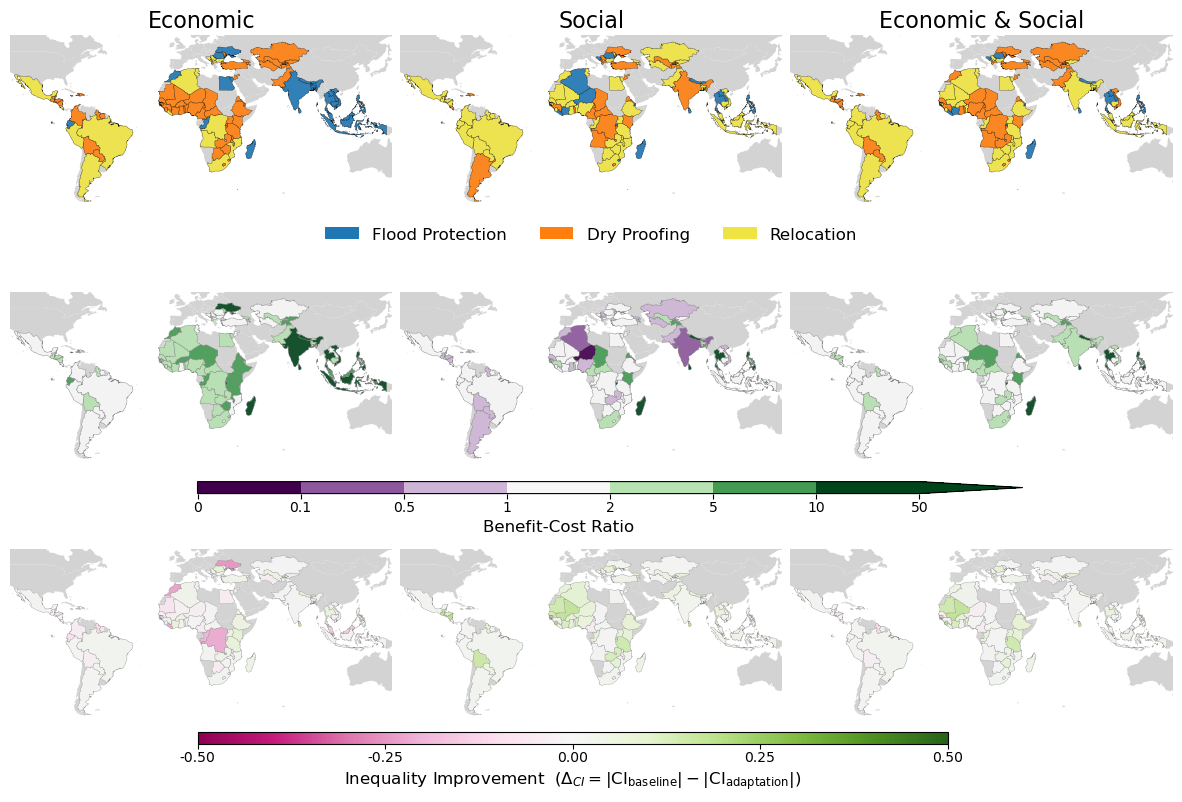

In [11]:
# --- Config ---
appraisals = {
    'Economic': economic_adaptation,
    'Social': social_adaptation,
    'Economic & Social': balanced_adaptation,
}
xmin, xmax, ymin, ymax = -120, 145, -60, 60

adapt_colors = {
    'flood_protection': '#1f77b4',
    'dry_proofing':     '#ff7f0e',
    'relocation':       '#F0E442',
}

# BCR discrete colormap
bcr_bounds = [0, 0.1, 0.5, 1, 2, 5, 10, 50]
n_bins = len(bcr_bounds) - 1
bcr_cmap = ListedColormap(plt.cm.PRGn(np.linspace(0, 1, n_bins)))
bcr_norm = BoundaryNorm(bcr_bounds, ncolors=n_bins, clip=False)

# CI delta colormap
ci_cmap = plt.cm.PiYG
ci_norm = Normalize(vmin=-0.5, vmax=0.5)

# Load world basemap once
world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")

# --- Create figure ---
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
plt.subplots_adjust(hspace=0.0, wspace=0.02)

for col_idx, (appraisal_name, df) in enumerate(appraisals.items()):
    map_df = df.copy()
    map_df['geometry'] = map_df['geometry'].simplify(tolerance=0.1)

    for row_idx in range(3):
        ax = axes[row_idx, col_idx]
        world.plot(ax=ax, color='lightgray')

        if row_idx == 0:  # Adaptation option
            map_df['color'] = map_df['adaptation'].map(adapt_colors)
            valid = ~map_df['color'].isna()
            map_df[valid].plot(ax=ax, color=map_df.loc[valid, 'color'],
                               edgecolor='black', linewidth=0.2, alpha=0.9)

        elif row_idx == 1:  # BCR
            valid = ~map_df['bcr'].isna()
            map_df[valid].plot(column='bcr', ax=ax, cmap=bcr_cmap, norm=bcr_norm,
                               edgecolor='gray', linewidth=0.3, alpha=0.9)

        elif row_idx == 2:  # CI delta
            valid = ~map_df['CI_delta'].isna()
            map_df[valid].plot(column='CI_delta', ax=ax, cmap=ci_cmap, norm=ci_norm,
                               edgecolor='gray', linewidth=0.2, alpha=0.9)

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_axis_off()

        # Column titles on top row
        if row_idx == 0:
            ax.set_title(appraisal_name, fontsize=16)

# --- Shared legends/colorbars below each row ---
# Row 0: categorical legend
legend_handles = [mpatches.Patch(facecolor=c, edgecolor='none', label=k.replace('_', ' ').title())
                  for k, c in adapt_colors.items()]
axes[0, 1].legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, -0.02),
                   ncol=3, frameon=False, fontsize=12)

# Row 1: BCR colorbar
cax1 = fig.add_axes([0.25, 0.38, 0.55, 0.012]) # [l, b, w, h]
bcr_bar_norm = BoundaryNorm(range(n_bins + 1), ncolors=n_bins)
cbar1 = ColorbarBase(cax1, cmap=bcr_cmap, norm=bcr_bar_norm,
                      boundaries=np.arange(n_bins + 1), orientation='horizontal',
                      spacing='uniform', extend='max', extendfrac='auto')
cbar1.set_ticks(np.arange(n_bins + 1))
cbar1.set_ticklabels([f"{b:g}" for b in bcr_bounds])
cbar1.ax.tick_params(labelsize=10, pad=1)
cbar1.set_label('Benefit-Cost Ratio', labelpad=4, fontsize=12)

# Row 2: CI delta colorbar
cax2 = fig.add_axes([0.25, 0.13, 0.5, 0.012])
sm = ScalarMappable(cmap=ci_cmap, norm=ci_norm)
sm.set_array([])
cbar2 = fig.colorbar(sm, cax=cax2, orientation='horizontal')
cbar2.set_ticks(np.linspace(-0.5, 0.5, 5))
cbar2.set_ticklabels([f"{v:.2f}" for v in np.linspace(-0.5, 0.5, 5)])
cbar2.ax.tick_params(labelsize=10, pad=1)
cbar2.set_label(r'Inequality Improvement  ($\Delta_{CI} = |\mathrm{CI}_{\mathrm{baseline}}| - |\mathrm{CI}_{\mathrm{adaptation}}|$)',
                labelpad=4, fontsize=12)

plt.show()

##### 8) Adaptation Stats

In [ ]:
scenarios = {
    'Economic': economic_adaptation,
    'Balanced': balanced_adaptation,
    'Social':   social_adaptation,
}

print(f"\n{'='*60}")
print(f"{'='*60}")
print(f"Flood Protection: ${cost_fp['adaptation_cost'].sum():,.0f}")
print(f"Dry Proofing: ${cost_dp['adaptation_cost'].sum():,.0f}")
print(f"Relocation: ${cost_rl['adaptation_cost'].sum():,.0f}")

for name, df in scenarios.items():
    print(f"\n{'='*60}")
    print(f"  {name.upper()} APPRAISAL")
    print(f"{'='*60}")

    # Adaptation counts
    print("\nAdaptation choices:")
    counts = df['adaptation'].value_counts()
    for opt, n in counts.items():
        print(f"  {opt.replace('_',' ').title():20s}: {n:3d} ({100*n/len(df):.1f}%)")

    # Total investment
    total_cost = df['adaptation_cost'].sum()
    print(f"\nTotal investment cost: ${total_cost:,.0f}")

    # BCR breakdown
    n_total = df['bcr'].notna().sum()
    for thresh in [1, 2, 5]:
        n = (df['bcr'] > thresh).sum()
        print(f"  BCR > {thresh}: {n:3d} / {n_total} ({100*n/n_total:.1f}%)")

    # CI stats
    print(f"\nCI baseline:   {df['CI_baseline'].mean():.4f} ± {df['CI_baseline'].std():.4f}")
    print(f"CI adapted:    {df['CI_adapted'].mean():.4f} ± {df['CI_adapted'].std():.4f}")
    print(f"CI change:     {df['CI_change'].mean():.4f} ± {df['CI_change'].std():.4f}")
    print(f"CI delta:     {df['CI_delta'].mean():.4f} ± {df['CI_delta'].std():.4f}")

    # CI delta direction
    n_improved = (df['CI_delta'] > 0).sum()
    n_worsened = (df['CI_delta'] < 0).sum()
    n_unchanged = (df['CI_delta'] == 0).sum()
    print(f"\nInequality decreased (ΔCI > 0): {n_improved:3d} ({100*n_improved/len(df):.1f}%)")
    print(f"Inequality increased (ΔCI < 0): {n_worsened:3d} ({100*n_worsened/len(df):.1f}%)")
    if n_unchanged > 0:
        print(f"No change            (ΔCI = 0): {n_unchanged:3d} ({100*n_unchanged/len(df):.1f}%)")